# RamanV2 光谱查看器

修改顶部配置后，先运行准备数据单元，再分别运行四个绘图单元。


In [14]:
"""RamanV2 光谱查看脚本。
修改顶部配置后，按顺序运行准备数据单元和四个绘图单元。
本 notebook 集中展示单条原始谱、基线校正谱、模型输入通道和文件夹原始谱。
"""

from __future__ import annotations

import random
from dataclasses import dataclass, replace
from pathlib import Path
from typing import Any

import numpy as np

from ramanv2.common.arc_data import read_arc_data
from ramanv2.common.naming import build_natural_key
from ramanv2.common.plotting import configure_matplotlib_fonts
from ramanv2.core.config import InputConfig, build_config
from ramanv2.core.input_spec import build_input_spec
from ramanv2.core.paths import PROJECT_ROOT
from ramanv2.data.config import DataBuildConfig, build_cosmic_ray_options, resolve_build_config
from ramanv2.data.profiles import get_dataset_dir, get_profile
from ramanv2.data.runtime.input import InputPreprocessor
from ramanv2.spectra.axis import build_wn_ref
from ramanv2.spectra.bands import build_valid_mask
from ramanv2.spectra.preprocess import estimate_baseline, remove_cosmic_rays


# ------------------------------ 顶部运行配置 ------------------------------
PROFILE_ID = "GN"

SAMPLE_PATH = "dataset/cosmic_data/delete/manual/20240106/ESK01/CELL12_Area01_001.arc_data"
SAMPLE_FOLDER = "dataset/cosmic_data/delete/manual/20240106/ESK01"
SAMPLE_SEED = 46

FOLDER_PATH = SAMPLE_FOLDER
BASELINE_DISPLAY_MIN = 600.0
BASELINE_DISPLAY_MAX = 1800.0
FOLDER_DISPLAY_MIN = None
FOLDER_DISPLAY_MAX = None



@dataclass(frozen=True)
class PreparedSpectrum:
    """保存一条谱的显示数据和模型输入通道。"""

    path: Path
    raw_wavenumbers: np.ndarray
    raw_intensity: np.ndarray
    cleaned_intensity: np.ndarray
    baseline_wavenumbers: np.ndarray
    baseline: np.ndarray
    corrected_wavenumbers: np.ndarray
    corrected_intensity: np.ndarray
    input_wavenumbers: np.ndarray
    model_channels: np.ndarray
    cosmic_ray_replaced: int



In [5]:
def find_sample_path(
    profile_id: str,
    sample_path: str | Path | None,
    sample_folder: str | Path | None,
    sample_seed: int | None,
    project_root: Path | str = PROJECT_ROOT,
) -> Path:
    """解析指定谱，或从指定目录稳定抽取一条谱。"""
    root = Path(project_root).resolve()
    if sample_path is not None:
        path = Path(sample_path)
        return path.resolve() if path.is_absolute() else (root / path).resolve()

    profile = get_profile(profile_id)
    dataset_dir = get_dataset_dir(profile, root)
    folder = Path(sample_folder) if sample_folder is not None else Path(profile.root_init)
    sample_root = folder if folder.is_absolute() else (root / folder)
    if not sample_root.exists() and not folder.is_absolute():
        sample_root = dataset_dir / folder
    candidates = sorted(
        sample_root.rglob("*.arc_data"),
        key=lambda path: build_natural_key(path.relative_to(sample_root).as_posix()),
    )
    if not candidates:
        raise FileNotFoundError(f"未找到 .arc_data 文件：{sample_root}")
    return random.Random(sample_seed).choice(candidates).resolve()


def collect_folder_spectra(folder_path: str | Path) -> list[Path]:
    """递归收集文件夹中的 `.arc_data`，并按自然顺序返回。"""
    folder = Path(folder_path).resolve()
    if not folder.is_dir():
        raise NotADirectoryError(f"文件夹不存在：{folder}")
    paths = sorted(
        folder.rglob("*.arc_data"),
        key=lambda path: build_natural_key(path.relative_to(folder).as_posix()),
    )
    if not paths:
        raise FileNotFoundError(f"未找到 .arc_data 文件：{folder}")
    return paths


def prepare_single_spectrum(
    spectrum_path: str | Path,
    input_config: InputConfig,
    build_values: DataBuildConfig | None = None,
    profile_id: str = PROFILE_ID,
) -> PreparedSpectrum:
    """完成单谱宇宙射线处理、基线校正和三通道模型输入构建。"""
    path = Path(spectrum_path).resolve()
    wavenumbers, raw_intensity = read_arc_data(path)
    if not wavenumbers.size or not raw_intensity.size:
        raise ValueError(f"无法读取光谱：{path}")

    build_config_value = resolve_build_config(build_values)
    cosmic_options = build_cosmic_ray_options(profile_id, build_config_value)
    cleaned_intensity = np.asarray(raw_intensity, dtype=np.float32)
    cosmic_stats = 0
    if cosmic_options["cosmic_ray_enable"]:
        cleaned_intensity, stats = remove_cosmic_rays(
            cleaned_intensity,
            window_points=cosmic_options["cosmic_ray_window_points"],
            threshold=cosmic_options["cosmic_ray_threshold"],
            max_iter=cosmic_options["cosmic_ray_max_iter"],
        )
        cosmic_stats = int(stats)

    fit_mask = (
        (wavenumbers >= build_config_value.baseline_fit_min)
        & (wavenumbers <= build_config_value.baseline_fit_max)
    )
    baseline_wavenumbers = np.asarray(wavenumbers[fit_mask], dtype=np.float32)
    baseline_input = np.asarray(cleaned_intensity[fit_mask], dtype=np.float32)
    if baseline_wavenumbers.size < 10:
        raise ValueError(f"基线拟合范围内的有效波数点不足：{path}")

    fit_valid_mask = build_valid_mask(baseline_wavenumbers, input_config.bad_bands)
    baseline = estimate_baseline(
        baseline_input,
        method=build_config_value.baseline_method,
        lam=build_config_value.baseline_lam,
        p=build_config_value.baseline_asls_p,
        niter=build_config_value.baseline_max_iter,
        valid_mask=fit_valid_mask,
    )
    corrected = baseline_input - baseline
    crop_mask = (
        (baseline_wavenumbers >= input_config.cut_min)
        & (baseline_wavenumbers <= input_config.cut_max)
    )
    corrected_wavenumbers = baseline_wavenumbers[crop_mask]
    corrected_intensity = np.asarray(corrected[crop_mask], dtype=np.float32)
    if corrected_wavenumbers.size < 10:
        raise ValueError(f"裁切范围内的有效波数点不足：{path}")

    input_wavenumbers = np.asarray(
        build_wn_ref(
            input_config.cut_min,
            input_config.cut_max,
            input_config.target_points,
        ),
        dtype=np.float32,
    )
    input_intensity = np.interp(
        input_wavenumbers,
        corrected_wavenumbers,
        corrected_intensity,
    ).astype(np.float32)

    # 查看器固定展示三条网络输入通道，但不改动训练和推理配置。
    display_config = replace(input_config, smooth_use=True, d1_use=True, bad_bands=())
    input_spec = build_input_spec(display_config)
    preprocessor = InputPreprocessor(input_spec, device="cpu")
    model_channels = preprocessor.preprocess_intensity(input_intensity)[0].numpy()
    return PreparedSpectrum(
        path=path,
        raw_wavenumbers=np.asarray(wavenumbers, dtype=np.float32),
        raw_intensity=np.asarray(raw_intensity, dtype=np.float32),
        cleaned_intensity=cleaned_intensity,
        baseline_wavenumbers=baseline_wavenumbers,
        baseline=np.asarray(baseline, dtype=np.float32),
        corrected_wavenumbers=corrected_wavenumbers,
        corrected_intensity=corrected_intensity,
        input_wavenumbers=input_wavenumbers,
        model_channels=np.asarray(model_channels, dtype=np.float32),
        cosmic_ray_replaced=cosmic_stats,
    )


def add_bad_band_spans(axis: Any, bad_bands: tuple[tuple[float, float], ...]) -> None:
    """在坐标轴上标记不参与输入的坏波段。"""
    for index, (lower, upper) in enumerate(bad_bands):
        axis.axvspan(
            lower,
            upper,
            color="gray",
            alpha=0.14,
            label="坏波段" if index == 0 else None,
        )


def style_axis(
    axis: Any,
    title: str,
    bad_bands: tuple[tuple[float, float], ...] = (),
    xlim: tuple[float, float] | None = None,
) -> None:
    """统一光谱图的坐标轴、范围和坏波段标记。"""
    add_bad_band_spans(axis, bad_bands)
    axis.set_title(title)
    axis.set_xlabel("拉曼位移 (cm$^{-1}$)")
    axis.set_ylabel("强度")
    if xlim is not None:
        axis.set_xlim(*xlim)
    axis.legend(loc="best")


def plot_raw_spectrum(prepared: PreparedSpectrum) -> None:
    """单独绘制一条原始谱。"""
    import matplotlib.pyplot as plt

    figure, axis = plt.subplots(figsize=(13, 5.5))
    axis.plot(
        prepared.raw_wavenumbers,
        prepared.raw_intensity,
        color="#4C72B0",
        linewidth=1.1,
        label="原始谱",
    )
    style_axis(axis, f"单条原始谱：{prepared.path.name}")
    figure.tight_layout()
    plt.show()


def plot_baseline_comparison(
    prepared: PreparedSpectrum,
    bad_bands: tuple[tuple[float, float], ...],
) -> None:
    """在限定横轴范围内对照原始谱和基线去除谱。"""
    import matplotlib.pyplot as plt

    figure, axis = plt.subplots(figsize=(13, 5.5))
    axis.plot(
        prepared.raw_wavenumbers,
        prepared.raw_intensity,
        color="#4C72B0",
        linewidth=1.1,
        label="原始谱",
    )
    raw_min = float(np.nanmin(prepared.raw_intensity))
    raw_max = float(np.nanmax(prepared.raw_intensity))
    raw_padding = max((raw_max - raw_min) * 0.05, 1.0)
    axis.set_ylim(raw_min - raw_padding, raw_max + raw_padding)
    style_axis(
        axis,
        f"原始谱与基线去除谱：{prepared.path.name}",
        bad_bands,
        (BASELINE_DISPLAY_MIN, BASELINE_DISPLAY_MAX),
    )
    axis.set_ylabel("原始强度")

    corrected_axis = axis.twinx()
    corrected_axis.plot(
        prepared.corrected_wavenumbers,
        prepared.corrected_intensity,
        color="#D62728",
        linewidth=1.1,
        label="基线去除谱",
    )
    corrected_axis.set_ylabel("去基线强度")
    corrected_axis.legend(loc="upper right")
    figure.tight_layout()
    plt.show()


def plot_model_input(prepared: PreparedSpectrum) -> None:
    """在一张图中展示原始、Smooth 和一阶导数三个输入通道。"""
    import matplotlib.pyplot as plt

    labels = ("原始归一化通道", "Smooth 通道", "一阶导数通道")
    colors = ("#E41A1C", "#2166D1", "#1B8A1B")
    figure, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
    for axis, values, label, color in zip(
        axes,
        prepared.model_channels,
        labels,
        colors,
    ):
        axis.plot(
            prepared.input_wavenumbers,
            values,
            color=color,
            linewidth=1.3,
            label=label,
        )
        style_axis(axis, label)
    figure.suptitle("网络输入三通道", y=0.995)
    figure.tight_layout()
    plt.show()


def plot_folder_spectra(folder_path: str | Path) -> None:
    """将文件夹中的全部原始谱逐条绘制。"""
    import matplotlib.pyplot as plt

    folder = Path(folder_path).resolve()
    spectrum_paths = collect_folder_spectra(folder)
    figure, axes = plt.subplots(
        len(spectrum_paths),
        1,
        figsize=(13, max(4.0, 3.2 * len(spectrum_paths))),
        squeeze=False,
    )
    for axis, path in zip(axes[:, 0], spectrum_paths):
        wavenumbers, intensity = read_arc_data(path)
        if not wavenumbers.size or not intensity.size:
            raise ValueError(f"无法读取光谱：{path}")
        axis.plot(wavenumbers, intensity, color="#4C72B0", linewidth=0.9)
        axis.set_title(path.relative_to(folder).as_posix(), fontsize=10)
        axis.set_ylabel("强度")
        if FOLDER_DISPLAY_MIN is not None and FOLDER_DISPLAY_MAX is not None:
            axis.set_xlim(FOLDER_DISPLAY_MIN, FOLDER_DISPLAY_MAX)
    axes[-1, 0].set_xlabel("拉曼位移 (cm$^{-1}$)")
    figure.suptitle(f"文件夹内全部原始光谱（{len(spectrum_paths)} 条）", y=1.002)
    figure.tight_layout()
    plt.show()


In [19]:
SAMPLE_PATH = "dataset/cosmic_data/delete/manual/20240106/ESK01/CELL2_Area01_001.arc_data"

## 准备单条谱数据

先运行这一块，后面四个绘图块可以分别运行。

In [20]:
configure_matplotlib_fonts()
profile = get_profile(PROFILE_ID)
input_config = build_config({"profile_id": PROFILE_ID}).input
build_values = resolve_build_config()
sample_path = find_sample_path(
    PROFILE_ID, SAMPLE_PATH, SAMPLE_FOLDER, SAMPLE_SEED
)
prepared = prepare_single_spectrum(
    sample_path, input_config, build_values, PROFILE_ID
)
print(f"读取光谱：{prepared.path}")
print(f"基线方法：{build_values.baseline_method}")
print(f"宇宙射线替换点数：{prepared.cosmic_ray_replaced}")


读取光谱：E:\Pythonproject\拉曼光谱分类\dataset\cosmic_data\delete\manual\20240106\ESK01\CELL2_Area01_001.arc_data
基线方法：airPLS
宇宙射线替换点数：0


## 单条原始谱


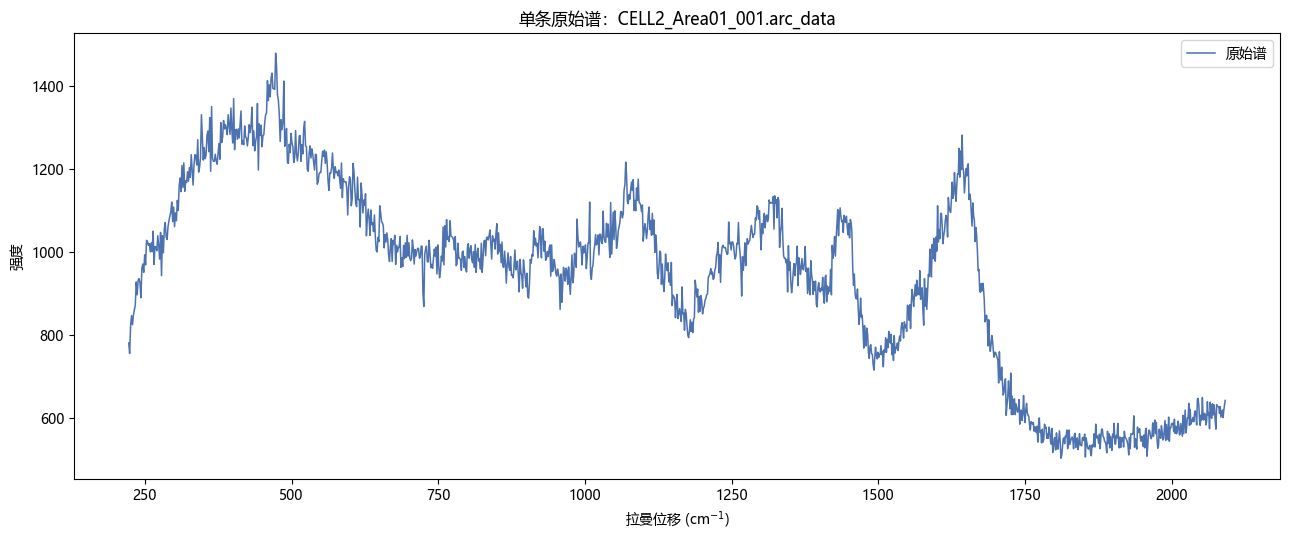

In [21]:
plot_raw_spectrum(prepared)


## 原始谱与基线去除谱


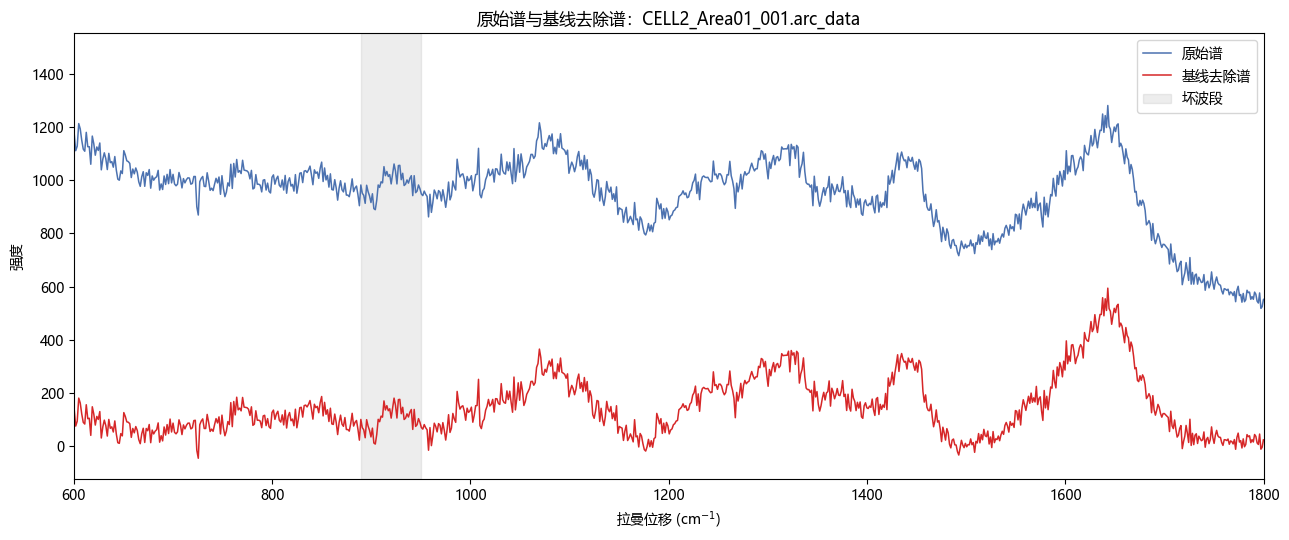

In [22]:
plot_baseline_comparison(prepared, input_config.bad_bands)


## 网络输入三通道


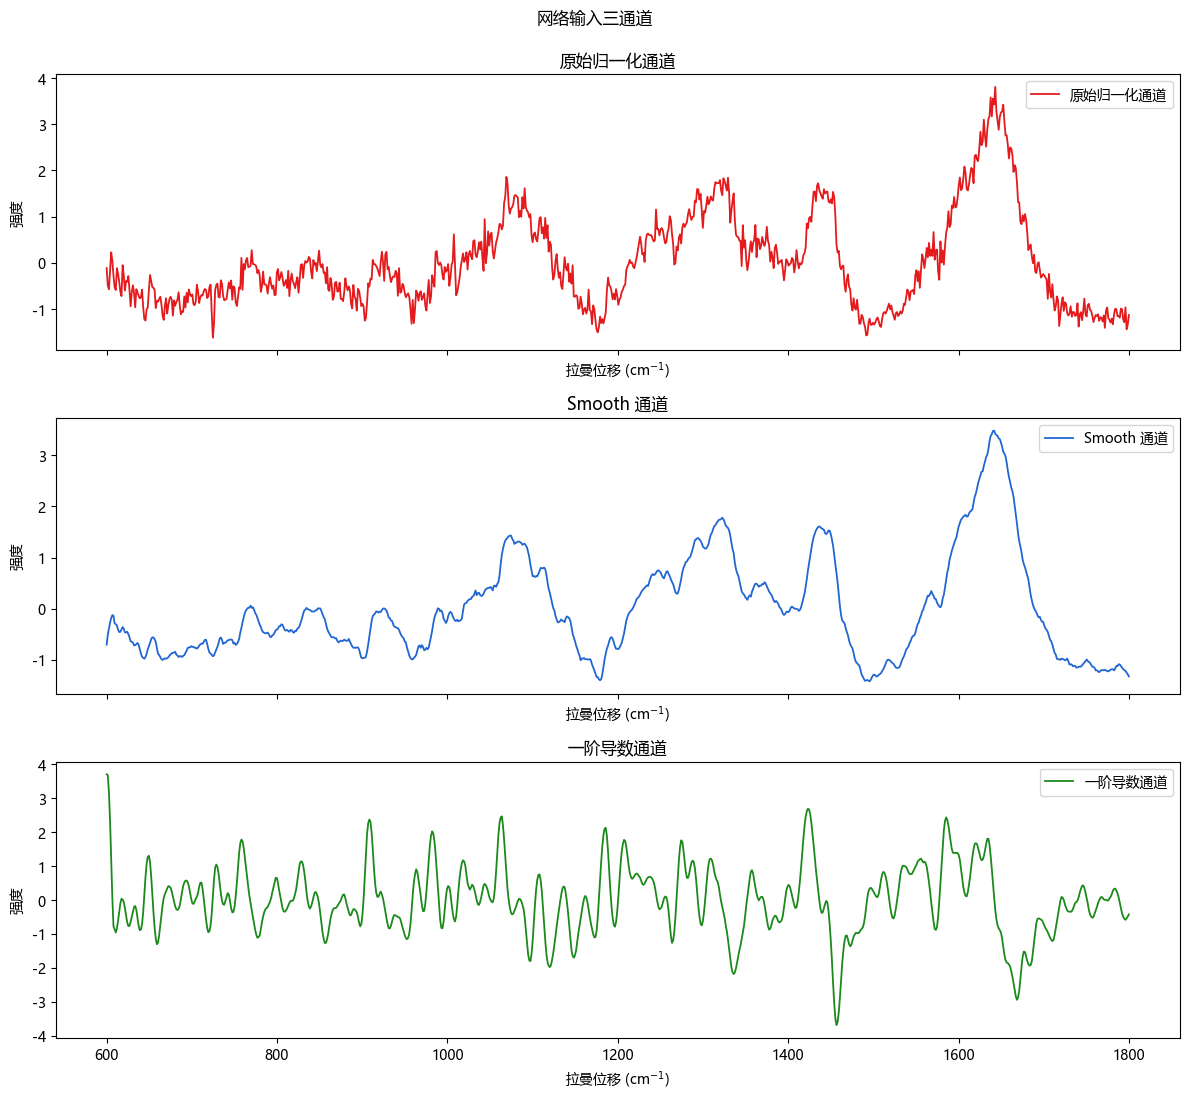

In [23]:
plot_model_input(prepared)


## 文件夹全部原始谱


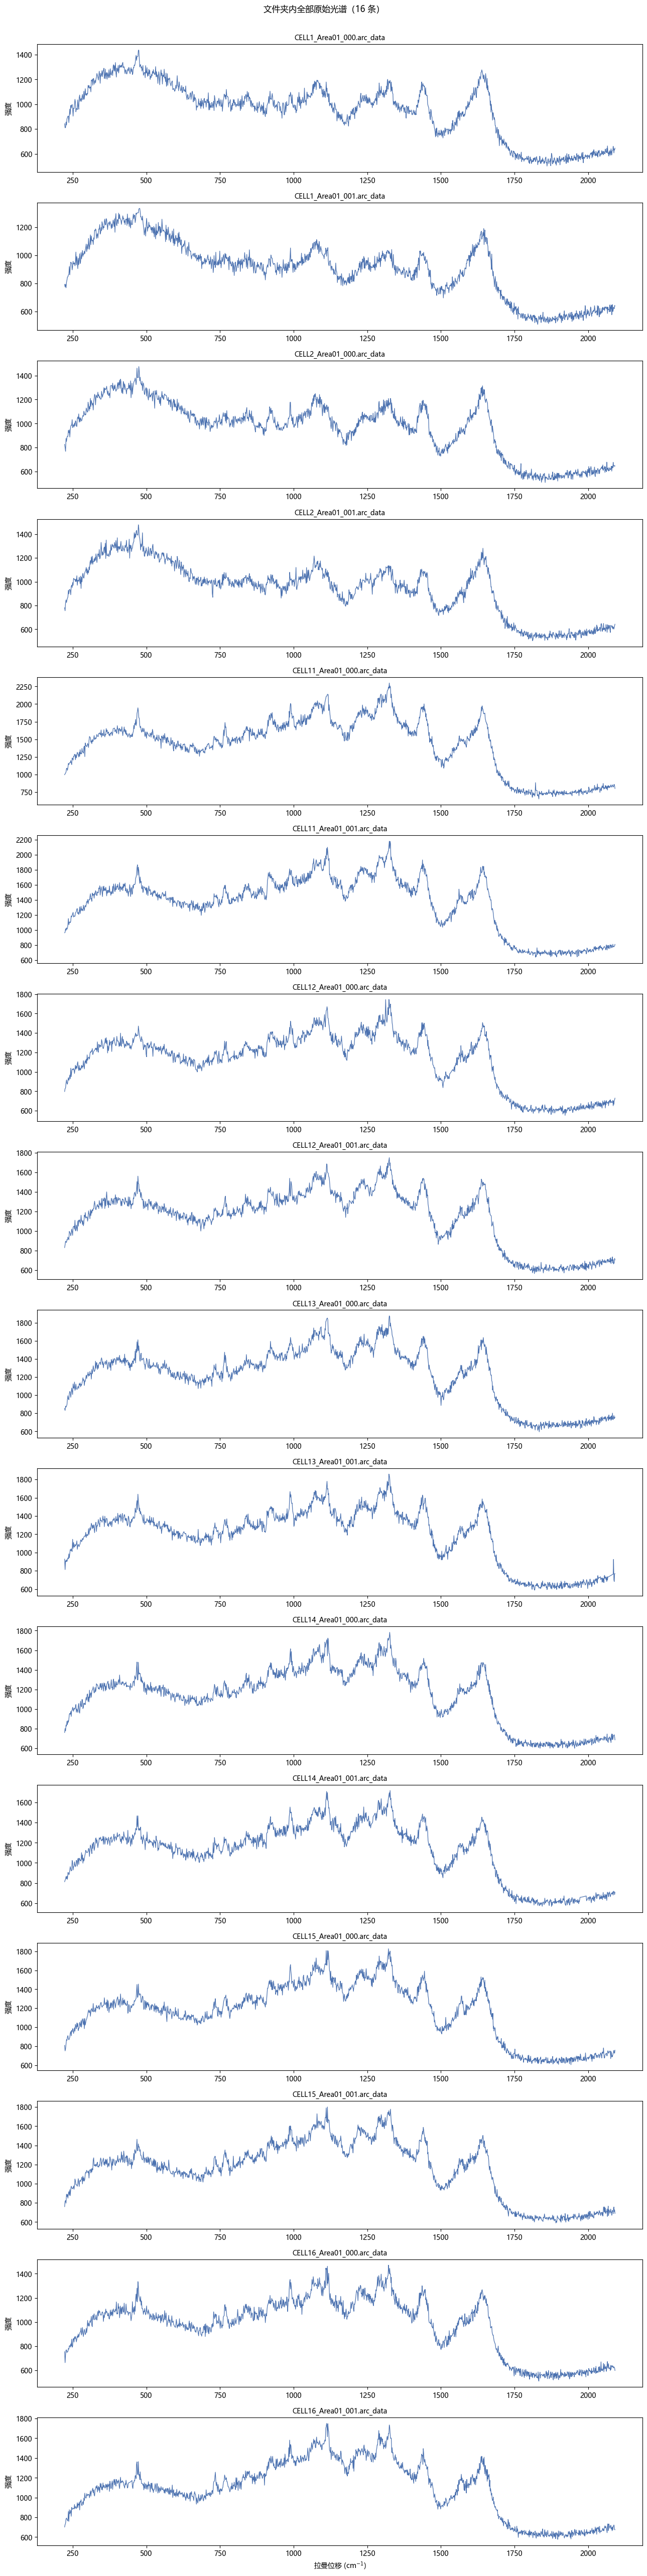

In [18]:
folder = Path(FOLDER_PATH)
if not folder.is_absolute():
    folder = PROJECT_ROOT / folder
plot_folder_spectra(folder)
